In [1]:
########################################
# Packages + global performance settings
########################################

using DelimitedFiles
using FiniteDiff
using ForwardDiff
using LineSearches
using LinearAlgebra
using Optim
using Plots
using Printf
using Random
using Statistics

# Small constants / safety floors
const KD_FLOOR = 1e-4
const KS_FLOOR = 0.0

# Label for output files
const RUN_ID = "BAU_no_damages"   # <-- change this for each sensitivity run



"BAU_no_damages"

In [2]:
#################################
# Parameters + initial conditions
#################################

struct Params
    # Time/grid
    Δt::Float64
    T::Int

    # Preferences
    ρ::Float64
    η::Float64

    # Growth & depreciation
    δ::Float64
    gL::Float64
    gA::Float64

    # Production primitives
    α::Float64
    σf::Float64
    σ0::Float64
    θd::Float64
    ϑc::Float64
    ξ::Float64

    # Production derived (used downstream)
    εf::Float64
    ε0::Float64
    θc::Float64
    ϕd::Float64
    ϕc::Float64
    ϕE::Float64
    ϕf::Float64

    # Adjustment / stranding
    χ::Float64
    χs::Float64
    vareps::Float64
    vareps2::Float64

    # Damages / climate
    ζ::Float64
    γ::Float64

    # Emissions intensity ψ(·)
    ψ1::Float64
    ψ2::Float64
    ψ3::Float64
    gψ::Float64

    # Tech change / learning
    gσ::Float64
    ω::Float64
    M0::Float64
    ϱ::Float64
    PBAU::Float64

    # Exogenous initial levels
    Y0::Float64   
    L0::Float64   

    # Initial state (effective-labour units)
    kf0::Float64
    kd0::Float64
    kc0::Float64
    ks0::Float64
    T0::Float64
    S0::Float64
    E0::Float64
    inner0::Float64
    y0_nodam::Float64
    A0::Float64
    Kd0_agg::Float64
end

# Derived parameters
function derive_production(σf, σ0, θd, ϑc)
    εf = (σf - 1) / σf
    ε0 = (σ0 - 1) / σ0
    θc = θd * ϑc / (1 - ϑc)

    ϕd = 1 / ((θc / θd)^(1 - ε0) + 1)
    ϕc = 1 - ϕd

    ϕE = 1 / (1 + (ϕc * θc^ε0 + ϕd * θd^ε0)^(εf/ε0 - 1) * ϕc * θc^(ε0 - 1))
    ϕf = 1 - ϕE

    return εf, ε0, θc, ϕd, ϕc, ϕE, ϕf
end

function default_params(; T::Int=201)
    # Time/grid
    Δt = 1.0

    # Preferences
    ρ = 0.011
    η = 1.35

    # Growth & depreciation
    δ  = 0.04
    gL = 0.0029
    gA = 0.02

    # Production primitives
    α  = 0.3
    σf = 0.2
    σ0 = 2.0
    θd = 0.1841 # ratio of dirty capital to final capital (kd+ξ)/kf (current alternative 0.216)
    ϑc = 0.16 # ratio of clean capital to all energy capital kc/(kc+kd+ξ)
    ξ  = 0.01

    εf, ε0, θc, ϕd, ϕc, ϕE, ϕf = derive_production(σf, σ0, θd, ϑc)

    # Adjustment / stranding
    χ   = 1.0
    χs  = 5.0
    vareps   = 300.0
    vareps2 = 0.004

    # Damages
    ζ = 0.0006
    γ = 0 # 0.0201

    # Emissions ψ
    ψ1 = 6.12 
    ψ2 = 0.729 
    ψ3 = 0.767 
    gψ = 0.01
    # Kd0_agg = 58.4

    # Tech change / learning
    gσ = 0.027
    ω  = 0.5
    M0 = 50.0
    ϱ  = 0.1
    PBAU = 53.2

    # Exogenous initial levels
    Y0 = 110.98
    L0 = 8.16
    
    # Initial states (effective-labour units)
    kf0 = 4.35
    kd0 = kf0 * θd - ξ # = Kd0_agg / (L0 * A0) # nb. would need to be calculated after A0
    kc0 = kf0 * θc # ϑc / (1 - ϑc) * (kd0 + ξ)
    ks0 = 0.0
    T0  = 1.38
    S0  = T0 / ζ
    E0 = (ϕd * (kd0 + ξ)^ε0 + ϕc * (kc0)^ε0)^(1 / ε0) # there is an unavoidable circularity because kd0 depends on A0 but A0 requires kd0
    inner0 = ϕf * kf0^εf + ϕE * E0^εf
    y0_nodam = inner0^(α / εf)
    A0 = (Y0 * exp(0.5 * γ * T0^2)) / (L0 * y0_nodam)
    Kd0_agg = kd0 * L0 * A0

    return Params(
    Δt, T,
    ρ, η,
    δ, gL, gA,
    α, σf, σ0, θd, ϑc, ξ,
    εf, ε0, θc, ϕd, ϕc, ϕE, ϕf,
    χ, χs, vareps, vareps2,
    ζ, γ,
    ψ1, ψ2, ψ3, gψ,
    gσ, ω, M0, ϱ, PBAU,
    Y0, L0,
    kf0, kd0, kc0, ks0, T0, S0,
    E0, inner0, y0_nodam, A0, Kd0_agg
)
end


default_params (generic function with 1 method)

In [3]:
########################
# Parameter diagnostics
########################

function print_group(io::IO, title::String, pairs)
    println(io, "\n", title)
    for (k, v) in pairs
        @printf(io, "  %-10s = %.16g\n", k, v)
    end
end

function check_params(p::Params)
    io = stdout

    print_group(io, "Time/grid", [
        ("Δt", p.Δt), ("T", p.T)
    ])

    print_group(io, "Preferences", [
        ("ρ", p.ρ), ("η", p.η)
    ])

    print_group(io, "Growth & depreciation", [
        ("δ", p.δ), ("gL", p.gL), ("gA", p.gA)
    ])

    print_group(io, "Production primitives", [
        ("α", p.α), ("σf", p.σf), ("σ0", p.σ0),
        ("θd", p.θd), ("ϑc", p.ϑc), ("ξ", p.ξ)
    ])

    print_group(io, "Production derived", [
        ("εf", p.εf), ("ε0", p.ε0), ("θc", p.θc),
        ("ϕd", p.ϕd), ("ϕc", p.ϕc), ("ϕE", p.ϕE), ("ϕf", p.ϕf)
    ])

    print_group(io, "Initial state", [
        ("kf0", p.kf0), ("kd0", p.kd0), ("Kd0_agg", p.Kd0_agg), ("kc0", p.kc0),
        ("ks0", p.ks0), ("T0", p.T0), ("A0", p.A0), ("S0", p.S0), ("E0", p.E0)
    ])

    # Sanity checks
    @assert abs((p.ϕc + p.ϕd) - 1) < 1e-10 "Energy weights don't sum to 1"
    @assert abs((p.ϕf + p.ϕE) - 1) < 1e-10 "Final/E weights don't sum to 1"
    @assert p.σf != 0 && p.σ0 != 0
    @assert p.θd > 0
    @assert 0 < p.ϑc < 1

    println("\nSanity checks: OK")
    return nothing
end

p = default_params()
check_params(p)



Time/grid
  Δt         = 1
  T          = 201

Preferences
  ρ          = 0.011
  η          = 1.35

Growth & depreciation
  δ          = 0.04
  gL         = 0.0029
  gA         = 0.02

Production primitives
  α          = 0.3
  σf         = 0.2
  σ0         = 2
  θd         = 0.1841
  ϑc         = 0.16
  ξ          = 0.01

Production derived
  εf         = -4
  ε0         = 0.5
  θc         = 0.03506666666666667
  ϕd         = 0.696167565299313
  ϕc         = 0.303832434700687
  ϕE         = 5.603266987417174e-05
  ϕf         = 0.9999439673301258

Initial state
  kf0        = 4.35
  kd0        = 0.790835
  Kd0_agg    = 57.31083432175345
  kc0        = 0.15254
  ks0        = 0
  T0         = 1.38
  A0         = 8.880975878708471
  S0         = 2300
  E0         = 0.5500625075506839

Sanity checks: OK


In [4]:
#################
# Math primitives
#################

@inline function softplus(x, vareps::Float64)
    z  = vareps * x
    zv = ForwardDiff.value(z)              # safe scalar for branch decision
    return (zv > 30.0) ? x : (log1p(exp(z)) / vareps)
end

@inline function exog_LA(t::Int, p::Params)
    L = p.L0 * (1.0 + p.gL)^t
    A = p.A0 * (1.0 + p.gA)^t
    return L, A
end

@inline damage_factor(S, p::Params) = exp(-0.5 * p.γ * (p.ζ*S)^2)

@inline function epsilon_energy(t::Int, S, p::Params)
    # Keep Mratio on the AD path when it's above 1; clamp only using a value-based branch.
    Mratio_raw = (p.M0 + p.PBAU*t - S + p.S0) / p.M0
    Mratio = (ForwardDiff.value(Mratio_raw) < 1.0) ? one(Mratio_raw) : Mratio_raw

    TC = p.ω * exp(-p.gσ * t) + (1.0 - p.ω) * Mratio^(-p.ϱ)
    ε  = 1.0 - TC / p.σ0
    σ  = p.σ0 / TC
    return ε, σ, Mratio, TC
end

@inline function energy(kd, kc, ε, p::Params)
    inside = p.ϕd * (kd + p.ξ)^ε + p.ϕc * (kc)^ε
    return inside^(1/ε)
end

@inline function output_y(kf, E, Ω, p::Params)
    inside = p.ϕf * kf^(p.εf) + p.ϕE * E^(p.εf)
    return inside^(p.α/p.εf) * Ω
end

@inline function emissions_P(kd, ks, t::Int, p::Params)
    L, A = exog_LA(t, p)
    AL = A * L

    tot = kd + ks
    if ForwardDiff.value(tot) <= 0.0
        return zero(tot)
    end

    term_exp = exp(-p.ψ2 * p.Kd0_agg * (ks / tot)) - exp(-p.ψ2 * p.Kd0_agg)
    hetero   = (p.ψ1 / p.ψ2) * (tot / p.Kd0_agg) * term_exp
    linear   = p.ψ3 * kd
    intensity = exp(-p.gψ * t) * (hetero + linear)

    return AL * intensity
end

nothing

In [5]:
################################
# One-step flows and transitions
################################

struct SimResult{T}
    kd::Vector{T}
    kc::Vector{T}
    kf::Vector{T}
    ks::Vector{T}
    S::Vector{T}

    P::Vector{T}
    E::Vector{T}
    y::Vector{T}
    c::Vector{T}

    ε::Vector{T}
    σ::Vector{T}
    Mratio::Vector{T}
    TC::Vector{T}

    Ω::Vector{T}
end

# AD-safe "floor": uses value() only for the branch decision
@inline function floor_if_needed(x, floorval)
    return (ForwardDiff.value(x) < floorval) ? floorval : x
end

@inline function nonneg_if_needed(x)
    return (ForwardDiff.value(x) < 0.0) ? zero(x) : x
end

# Exact kink operators (AD-safe): no softplus, but avoid tracer-in-boolean
@inline function pospart_if_needed(x)
    return (ForwardDiff.value(x) > 0.0) ? x : zero(x)   # max(x, 0)
end

@inline function negpart_if_needed(x)
    return (ForwardDiff.value(x) < 0.0) ? -x : zero(x)  # max(-x, 0)
end

"""
simulate(...; smooth_id_split=true)

If smooth_id_split=true (default): use the existing softplus-based smoothing
for the dirty investment sign split / stranding flow.

If smooth_id_split=false: completely eliminate softplus from the stranding /
dirty-investment decomposition by using exact kink operators:
  id_pos    = max(id,0)
  negpart   = max(-id,0)
  strand_flow = max(-id,0)  (=> exactly zero at id=0)
This change is ONLY in the economic model block; it does not affect optimiser
penalty smoothers such as softplus_plain.
"""
function simulate(p::Params, id, ic, iF; smooth_id_split::Bool = false)
    T = p.T
    @assert length(id) == T
    @assert length(ic) == T
    @assert length(iF) == T

    Tnum = promote_type(eltype(id), eltype(ic), eltype(iF), Float64)

    kd = Vector{Tnum}(undef, T+1)
    kc = Vector{Tnum}(undef, T+1)
    kf = Vector{Tnum}(undef, T+1)
    ks = Vector{Tnum}(undef, T+1)
    S  = Vector{Tnum}(undef, T+1)

    P  = Vector{Tnum}(undef, T)
    E  = Vector{Tnum}(undef, T)
    y  = Vector{Tnum}(undef, T)
    c  = Vector{Tnum}(undef, T)

    εv = Vector{Tnum}(undef, T)
    σv = Vector{Tnum}(undef, T)
    Mr = Vector{Tnum}(undef, T)
    TC = Vector{Tnum}(undef, T)

    Ω  = Vector{Tnum}(undef, T)

    kd[1] = Tnum(p.kd0)
    kc[1] = Tnum(p.kc0)
    kf[1] = Tnum(p.kf0)
    ks[1] = Tnum(p.ks0)
    S[1]  = Tnum(p.S0)

    decay_eff = p.δ + p.gL + p.gA
    decay = (1.0 - decay_eff)^(p.Δt)

    kd_floor = Tnum(KD_FLOOR)
    kc_floor = Tnum(KD_FLOOR)
    kf_floor = Tnum(KD_FLOOR)
    ks_floor = Tnum(KS_FLOOR)

    @inbounds for t in 0:(T-1)
        i = t + 1

        # Floors for denominators etc (AD-safe)
        kdi = floor_if_needed(kd[i], kd_floor)
        kci = floor_if_needed(kc[i], kc_floor)
        kfi = floor_if_needed(kf[i], kf_floor)
        ksi = floor_if_needed(ks[i], ks_floor)

        Ω[i] = damage_factor(S[i], p)

        εi, σi, Mri, TCi = epsilon_energy(t, S[i], p)
        εv[i] = Tnum(εi)
        σv[i] = Tnum(σi)
        Mr[i] = Tnum(Mri)
        TC[i] = Tnum(TCi)

        E[i] = energy(kdi, kci, εv[i], p)
        y[i] = output_y(kfi, E[i], Ω[i], p)
        P[i] = emissions_P(kdi, ksi, t, p)

        S[i+1] = S[i] + P[i] * p.Δt

        # Adjustment costs
        adj_f = p.χ * (iF[i]^2) / kfi
        adj_c = p.χ * (ic[i]^2) / kci
        adj_d = p.χ * (id[i]^2) / kdi

        # ----------------------------
        # Dirty investment decomposition
        # ----------------------------

        local id_pos::Tnum
        local negpart::Tnum
        local strand_flow::Tnum

        if smooth_id_split
            # Existing softplus-based smoothing (unchanged)
            id_pos = softplus(id[i], p.vareps)

            strand_flow = softplus(-id[i] + p.vareps2, p.vareps) - p.vareps2
            strand_flow = nonneg_if_needed(strand_flow)

            negpart = softplus(-id[i], p.vareps)
        else
            # Exact kink (NO softplus): eliminates tiny stranding costs at id=0
            id_pos = pospart_if_needed(id[i])       # max(id,0)
            negpart = negpart_if_needed(id[i])      # max(-id,0)

            # Natural exact stranding flow when "negative investment" retires dirty capital
            strand_flow = negpart                   # => exactly zero at id >= 0
        end

        Θ = p.χs * (negpart^2) / kdi

        # Consumption
        c[i] = y[i] - iF[i] - ic[i] - id_pos - Θ

        # Capital laws of motion
        kf[i+1] = decay * kfi + iF[i]*p.Δt - adj_f*p.Δt
        kc[i+1] = decay * kci + ic[i]*p.Δt - adj_c*p.Δt

        # Weight for allocating adjustment costs to the "positive" side of id
        # (Avoid softplus in the exact-kink branch)
        posweight = id_pos / (id_pos + negpart + Tnum(1e-12))

        kd_next = decay * kdi + id[i]*p.Δt - posweight * adj_d * p.Δt
        kd[i+1] = floor_if_needed(kd_next, kd_floor)

        ks_next = decay * ksi + strand_flow * p.Δt
        ks[i+1] = floor_if_needed(ks_next, ks_floor)
    end

    return SimResult{Tnum}(kd, kc, kf, ks, S, P, E, y, c, εv, σv, Mr, TC, Ω)
end

nothing


In [6]:
#########
# Welfare
#########

@inline function u_crra(c, η::Float64)
    if η == 1.0
        return log(c)
    else
        return c^(1.0-η) / (1.0-η)
    end
end

function welfare(sim::SimResult{T}, p::Params) where {T}
    Tnum = eltype(sim.c)
    W = zero(Tnum)

    const_penalty = Tnum(-10.0)
    slope_penalty = Tnum(1000.0)

    r_minus_g = p.ρ - p.gL + (p.η - 1.0) * p.gA

    @inbounds for t in 0:(p.T-1)
        c = sim.c[t+1]

        if ForwardDiff.value(c) > 0.0
            df = exp(-r_minus_g * t)              # X(t)
            per = u_crra(c, p.η) * df * p.Δt      # * Δt

            # Terminal perpetuity at final period (t = 200 when p.T = 201)
            if t == p.T - 1 && r_minus_g > 0
                per /= r_minus_g                  # / (r-g)
            end

            W += per
        else
            W += const_penalty + slope_penalty * c
        end
    end

    return W
end

nothing

In [7]:
######################
# Optimisation wrapper
######################

function unpack_controls(z::AbstractVector, p::Params)
    T = p.T
    @assert length(z) == 3*T
    id = @view z[1:T]
    ic = @view z[T+1:2T]
    iF = @view z[2T+1:3T]
    return id, ic, iF
end

function objective(z::AbstractVector, p::Params)
    id, ic, iF = unpack_controls(z, p)
    sim = simulate(p, id, ic, iF)
    return -welfare(sim, p)
end

# Build a cached ForwardDiff gradient config (much faster, fewer allocations)
function make_objgrad(p::Params, z0::AbstractVector)
    f(z) = objective(z, p)
    cfg = ForwardDiff.GradientConfig(f, z0)
    function g!(G, z)
        ForwardDiff.gradient!(G, f, z, cfg)
        return G
    end
    return f, g!
end

nothing

In [8]:
###########
# Optimiser (Fminbox + L-BFGS, numerical-stability penalties only)
###########

p = default_params()
T = p.T

# Bounds
id_lo, id_hi = -0.30,  1.00
ic_lo, ic_hi =  0.00,  1.00
iF_lo, iF_hi =  0.00,  2.00

lower = vcat(fill(id_lo, T), fill(ic_lo, T), fill(iF_lo, T))
upper = vcat(fill(id_hi, T), fill(ic_hi, T), fill(iF_hi, T))

marg = 1e-4

# Known-good constant start (use this for restart 1)
z_bestguess = vcat(
    fill(0.053, T),   # i_d
    fill(0.010, T),   # i_c
    fill(0.29,  T)    # i_f
)
z_bestguess = clamp.(z_bestguess, lower .+ 10marg, upper .- 10marg)

# ----------------------------
# Start generators
# ----------------------------

function jittered_start(zbase, lower, upper; scale=0.005)
    width = upper .- lower
    z = zbase .+ scale .* width .* (2 .* rand(length(zbase)) .- 1)
    return clamp.(z, lower .+ 1e-4, upper .- 1e-4)
end

function smooth_random_start(zbase, lower, upper; amp=0.15, nknots=8)
    T = length(zbase) ÷ 3
    width = upper .- lower

    function smooth_vec(T; nknots=8)
        knots = randn(nknots)
        xk = range(0, 1, length=nknots)
        xt = range(0, 1, length=T)
        v = similar(collect(xt))
        for i in 1:T
            x = xt[i]
            j = searchsortedlast(xk, x)
            j = clamp(j, 1, nknots-1)
            w = (x - xk[j]) / (xk[j+1] - xk[j])
            v[i] = (1-w)*knots[j] + w*knots[j+1]
        end
        m = maximum(abs.(v))
        return (m > 0) ? (v ./ m) : v
    end

    id = smooth_vec(T; nknots=nknots)
    ic = smooth_vec(T; nknots=nknots)
    iF = smooth_vec(T; nknots=nknots)

    z = copy(zbase)
    z[1:T]              .+= amp .* width[1:T]              .* id
    z[T+1:2*T]          .+= amp .* width[T+1:2*T]          .* ic
    z[2*T+1:3*T]        .+= amp .* width[2*T+1:3*T]        .* iF

    return clamp.(z, lower .+ 1e-4, upper .- 1e-4)
end

# ----------------------------
# Numerical-stability penalties (NOT economic)
# ----------------------------

# Softplus that branches on VALUE (AD-safe)
@inline function softplus_plain(x, k::Float64=80.0)
    z = k * x
    zv = ForwardDiff.value(z)
    return (zv > 30.0) ? x : (log1p(exp(z)) / k)
end

"""
Barrier-like penalty to keep c >= ϵ (utility existence + numerical stability).
NOT an economic constraint (no c>=1).
"""
function c_eps_penalty(sim, ϵ::Float64, λ::Float64)
    pen = zero(eltype(sim.c))
    @inbounds for ci in sim.c
        gap = softplus_plain(ϵ - ci, 80.0)   # ≈ max(ϵ-ci, 0)
        pen += gap * gap
    end
    return λ * pen
end

# ----------------------------
# One run
# ----------------------------

function run_once(p::Params, lower, upper, zstart;
                  mu0=1e-3, iters=1200, showtrace=false,
                  ϵ::Float64=1e-3, λϵ::Float64=1e12)

    T = p.T
    zstart = clamp.(zstart, lower .+ 1e-4, upper .- 1e-4)

    function f(z)
        id = view(z, 1:T)
        ic = view(z, T+1:2*T)
        iF = view(z, 2*T+1:3*T)

        sim = simulate(p, id, ic, iF)

        # Numerical-stability guards ONLY
        if any(x -> !isfinite(ForwardDiff.value(x)), sim.c)
            return 1e20
        end

        cmin = minimum(sim.c)
        if ForwardDiff.value(cmin) < 0.0
            return 1e22 + 1e16 * (softplus_plain(-cmin, 40.0))^2
        end
        if ForwardDiff.value(cmin) < 1e-8
            return 1e20 + 1e14 * (softplus_plain(1e-8 - cmin, 40.0))^2
        end

        obj = -welfare(sim, p)

        # ε-barrier (stability only)
        obj += c_eps_penalty(sim, ϵ, λϵ)

        return obj
    end

    cfg = ForwardDiff.GradientConfig(f, zstart)
    function g!(G, z)
        ForwardDiff.gradient!(G, f, z, cfg)
        return G
    end

    od = OnceDifferentiable(f, g!, zstart)

    opts = Optim.Options(
        iterations = iters,
        x_reltol = 1e-9,
        g_tol = 1e-7,
        f_reltol = 1e-9,
        show_trace = showtrace,
        show_every = 10
    )

    inner = LBFGS(linesearch = LineSearches.BackTracking(order=3))
    res = optimize(od, lower, upper, zstart, Fminbox(inner; mu0=mu0), opts)
    zstar = Optim.minimizer(res)

    # Evaluate TRUE welfare (no penalties) for reporting
    id_star = collect(view(zstar, 1:T))
    ic_star = collect(view(zstar, T+1:2*T))
    iF_star = collect(view(zstar, 2*T+1:3*T))
    sim_star = simulate(p, id_star, ic_star, iF_star)

    W = welfare(sim_star, p)
    cmin_true = minimum(sim_star.c)

    return res, zstar, W, cmin_true
end

# ----------------------------
# MULTI-START DRIVER (best-tracking + keep top-K) + TOURNAMENT POLISH
# ----------------------------

Random.seed!(1)

n_local  = 20
n_global = 10

# Stability params (NOT economic)
ϵ = 1e-3
λϵ = 1e12

const K = 5
topW = fill(-Inf, K)
topz = [copy(z_bestguess) for _ in 1:K]
topc = fill(NaN, K)

bestW = -Inf
bestz = copy(z_bestguess)
bestc = NaN

# Optional warm start for sensitivity analysis: # set z_warm = z_star, which is previous optimum when you have it; else leave as nothing.
z_warm = nothing

function maybe_insert!(W, z, cmin)
    if !(isfinite(W) && (cmin > 1e-8))
        return
    end
    j = argmin(topW)
    if W > topW[j]
        topW[j] = W
        topz[j] = copy(z)
        topc[j] = cmin
    end
end

for k in 1:(n_local + n_global)
    z0 =
        if k == 1
            (z_warm === nothing) ? z_bestguess : clamp.(z_warm, lower .+ marg, upper .- marg)
        elseif k <= n_local
            jittered_start(bestz, lower, upper; scale=0.005)
        else
            if isodd(k)
                jittered_start(bestz, lower, upper; scale=0.10)
            else
                smooth_random_start(bestz, lower, upper; amp=0.20, nknots=8)
            end
        end

    res, z, W, cmin = run_once(
        p, lower, upper, z0;
        mu0 = (k==1 ? 1e-3 : 1e-6),
        iters = 1500,
        showtrace = false,
        ϵ = ϵ,
        λϵ = λϵ
    )

    @printf("restart %2d: W = %.9f, min(c)=%.6g, converged=%s\n",
            k, W, cmin, string(Optim.converged(res)))

    # Update best-tracking (only valid utility)
    if isfinite(W) && (cmin > 1e-8) && (W > bestW)
        bestW = W
        bestz = copy(z)
        bestc = cmin
    end

    # Maintain top-K pool
    maybe_insert!(W, z, cmin)
end

println("\nBEST after multi-start (pre-polish): W = ", bestW, "   (min(c) = ", bestc, ")")

# Sort top-K
ord = sortperm(topW, rev=true)
topW = topW[ord]; topz = topz[ord]; topc = topc[ord]

println("\nTOP-$K after multi-start (pre-polish):")
for j in 1:K
    if isfinite(topW[j])
        @printf("  #%d: W = %.12f   min(c)=%.6f\n", j, topW[j], topc[j])
    end
end

# ----------------------------
# Tournament polish: polish only valid entries
# ----------------------------

valid_idx = findall(isfinite, topW)
polish_iters = 30000
polish_mu0   = 1e-6

bestW_pol = bestW
bestz_pol = copy(bestz)
bestc_pol = bestc

println("\nTOURNAMENT POLISH:")
for j in valid_idx
    res_pol, z_pol, W_pol, cmin_pol = run_once(
        p, lower, upper, topz[j];
        mu0 = polish_mu0,
        iters = polish_iters,
        showtrace = false,
        ϵ = ϵ,
        λϵ = λϵ
    )

    @printf("  polish #%d: W = %.12f   min(c)=%.6f   converged=%s\n",
            j, W_pol, cmin_pol, string(Optim.converged(res_pol)))

    if isfinite(W_pol) && (cmin_pol > 1e-8) && (W_pol > bestW_pol)
        bestW_pol = W_pol
        bestz_pol = z_pol
        bestc_pol = cmin_pol
    end
end

println("\nBEST after tournament polish: W = ", bestW_pol, "   (min(c) = ", bestc_pol, ")")

# Final unpack
z_star = bestz_pol
id_star = collect(view(z_star, 1:T))
ic_star = collect(view(z_star, T+1:2*T))
iF_star = collect(view(z_star, 2*T+1:3*T))

sim_star = simulate(p, id_star, ic_star, iF_star)
# println("Final welfare (no penalties) = ", welfare(sim_star, p))
# println("Final min(c) (no penalties)  = ", minimum(sim_star.c))
nothing

restart  1: W = -178.934529210, min(c)=0.868459, converged=true
restart  2: W = -178.934530475, min(c)=0.868298, converged=true
restart  3: W = -178.934530952, min(c)=0.868413, converged=true
restart  4: W = -178.934530077, min(c)=0.868758, converged=true
restart  5: W = -178.934528900, min(c)=0.868027, converged=true
restart  6: W = -178.934533547, min(c)=0.868411, converged=true
restart  7: W = -178.934530228, min(c)=0.867859, converged=true
restart  8: W = -178.934528432, min(c)=0.868229, converged=true
restart  9: W = -178.934533323, min(c)=0.86773, converged=true
restart 10: W = -178.934532664, min(c)=0.86863, converged=true
restart 11: W = -178.934533495, min(c)=0.868167, converged=true
restart 12: W = -178.934539934, min(c)=0.866856, converged=true
restart 13: W = -178.934530126, min(c)=0.868127, converged=true
restart 14: W = -178.934530507, min(c)=0.868175, converged=true
restart 15: W = -178.934530903, min(c)=0.868482, converged=true
restart 16: W = -178.934529226, min(c)=0.8

Year   t     Emissions P(t)        i_d(t)              i_c(t)
2025    0         52.35247165          0.05644851          0.00780423
2026    1         53.20090244          0.05672247          0.00761499
2027    2         54.06791193          0.05685051          0.00744374
2028    3         54.94498598          0.05693528          0.00726724
2029    4         55.82981155          0.05707181          0.00711067
2030    5         56.72583979          0.05717304          0.00695562
2031    6         57.63116101          0.05727695          0.00680768
2032    7         58.54623723          0.05737556          0.00666374
2033    8         59.47102410          0.05746413          0.00652343
2034    9         60.40517532          0.05755163          0.00638935
2035   10         61.34892526          0.05764258          0.00625980
2036   11         62.30280004          0.05771620          0.00613449
2037   12         63.26594560          0.05781070          0.00601557
2038   13         64.2400766

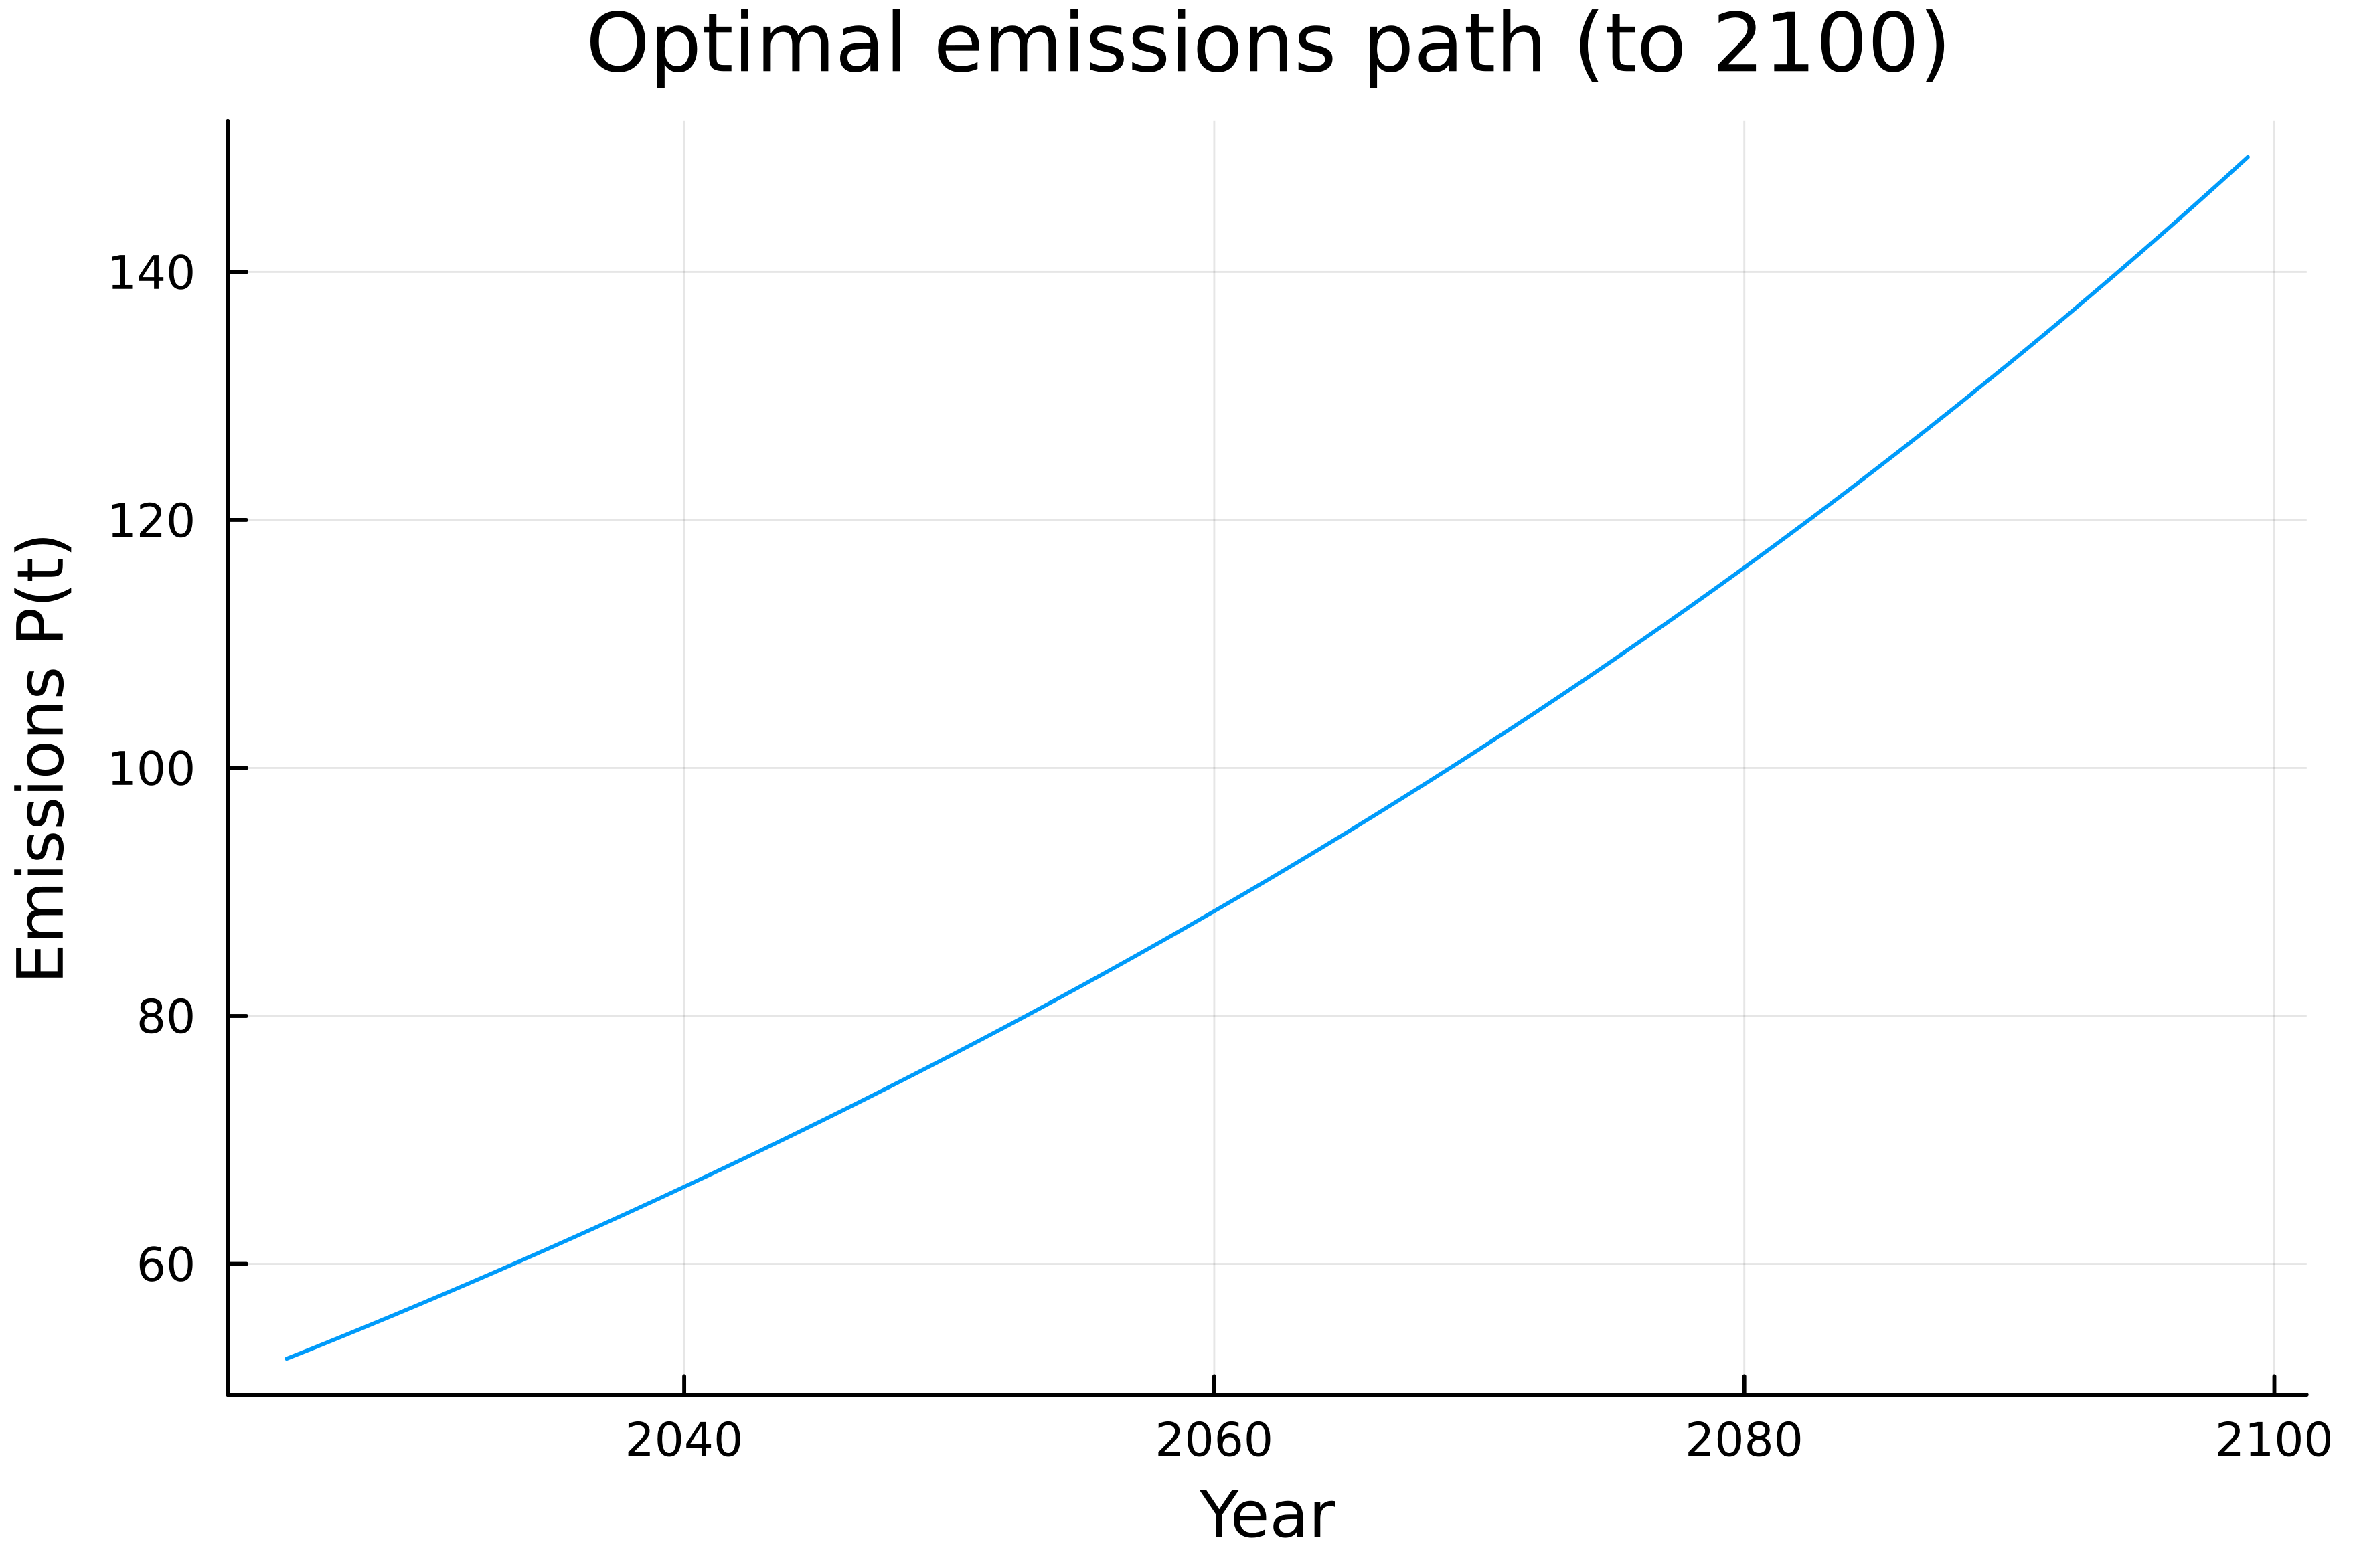

In [9]:
############################################
# Inspect + plot optimal paths to 2100 (t=0:74)
############################################

base_year = 2025          # change if needed
Tplot = min(75, p.T)

t = collect(0:(Tplot-1))
years = base_year .+ t

emissions = sim_star.P[1:Tplot]
i_d = id_star[1:Tplot]
i_c = ic_star[1:Tplot]

# ---- Print table ----
println("Year   t     Emissions P(t)        i_d(t)              i_c(t)")
for i in 1:Tplot
    @printf("%4d  %3d  %18.8f  %18.8f  %18.8f\n",
            years[i], t[i], emissions[i], i_d[i], i_c[i])
end

# ---- Summary stats ----
println("\nSummary stats (first $Tplot periods):")
@printf("Emissions: min=%g  max=%g  mean=%g\n", minimum(emissions), maximum(emissions), mean(emissions))
@printf("i_d:       min=%g  max=%g  mean=%g\n", minimum(i_d),       maximum(i_d),       mean(i_d))
@printf("i_c:       min=%g  max=%g  mean=%g\n", minimum(i_c),       maximum(i_c),       mean(i_c))

# ---- Plots ----
plot(years, emissions,
     xlabel="Year", ylabel="Emissions P(t)",
     title="Optimal emissions path (to 2100)", legend=false)

#plot(years, i_d,
     #xlabel="Year", ylabel="i_d(t)",
     #title="Optimal dirty investment control (to 2100)", legend=false)

#plot(years, i_c,
     #xlabel="Year", ylabel="i_c(t)",
     #title="Optimal clean investment control (to 2100)", legend=false)


In [10]:
############################################
# Export optimal controls to CSV for Excel
############################################

# expects: const RUN_ID defined earlier (top of notebook)
# e.g. const RUN_ID = "gamma_up10"

@assert isdefined(Main, :RUN_ID) "Define const RUN_ID = \"...\" near the top of the notebook."
println("\n=== EXPORT CONTROLS | RUN_ID = $(RUN_ID) ===\n")

base_year = 2025
T = p.T
t = collect(0:(T-1))
year = base_year .+ t

# Controls (optimal)
i_d = id_star
i_c = ic_star
i_f = iF_star

# Filename with run label
fname = "optimal_controls__$(RUN_ID).csv"

# Header + data matrix
header = ["year", "t", "i_d", "i_c", "i_f"]
data = hcat(year, t, i_d, i_c, i_f)

open(fname, "w") do io
    write(io, join(header, ",") * "\n")  # header across top
    writedlm(io, data, ',')
end

println("Wrote: ", abspath(fname))


=== EXPORT CONTROLS | RUN_ID = BAU_no_damages ===

Wrote: c:\Users\DIETZS\OneDrive - London School of Economics\Documents\GitHub\As_If_The_Transition_Matters\Julia model\optimal_controls__BAU_no_damages.csv


In [11]:
############################################################
# Export key outputs (incl. SCC) from the optimal simulation
############################################################

@assert isdefined(Main, :RUN_ID) "Define const RUN_ID = \"...\" near the top of the notebook."
println("\n=== EXPORT OUTPUTS | RUN_ID = $(RUN_ID) ===\n")

base_year = 2025
T = p.T
t = collect(0:(T-1))
year = base_year .+ t

# Exogenous scale factors AL(t)
AL = Vector{Float64}(undef, T)
@inbounds for i in 1:T
    L, A = exog_LA(t[i], p)
    AL[i] = A * L
end

# Controls
i_d = id_star
i_c = ic_star
i_f = iF_star

# Core outputs
P    = sim_star.P[1:T]
S    = sim_star.S[1:T]
Temp = p.ζ .* S

kd = sim_star.kd[1:T]
kc = sim_star.kc[1:T]
kf = sim_star.kf[1:T]
ks = sim_star.ks[1:T]  # if you prefer ks_end, swap to sim_star.ks[2:T+1]

# Aggregates
E_agg = sim_star.E[1:T] .* AL
Y_agg = sim_star.y[1:T] .* AL
C_agg = sim_star.c[1:T] .* AL

# SCC (Excel-style): r = ρ - gL + η*gA
r = p.ρ - p.gL + p.η * p.gA
time = p.Δt .* t
disc = exp.(-r .* time)
flow = disc .* Y_agg .* p.γ .* p.ζ .* Temp

SCC = Vector{Float64}(undef, T)
@inbounds for i in 1:T
    pv = sum(flow[i:end]) * p.Δt
    SCC[i] = 1000.0 * exp(r * time[i]) * pv
end

header = [
    "year","t",
    "i_d","i_c","i_f",
    "P_emissions","Temp",
    "kd","kc","kf",
    "ks",
    "E_agg","Y_agg","C_agg",
    "SCC"
]

data = hcat(
    year, t,
    i_d, i_c, i_f,
    P, Temp,
    kd, kc, kf,
    ks,
    E_agg, Y_agg, C_agg,
    SCC
)

fname = "optimal_outputs__$(RUN_ID).csv"
open(fname, "w") do io
    write(io, join(header, ",") * "\n")
    writedlm(io, data, ',')
end

println("Wrote: ", abspath(fname))



=== EXPORT OUTPUTS | RUN_ID = BAU_no_damages ===

Wrote: c:\Users\DIETZS\OneDrive - London School of Economics\Documents\GitHub\As_If_The_Transition_Matters\Julia model\optimal_outputs__BAU_no_damages.csv
